# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

/Users/lunavathsangeetha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
# Load CIFAR-10 Dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Train labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1492s 9us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Train labels shape: (50000, 1)
Test labels shape: (10000, 1)


## 🖼️ Visualize Sample Images

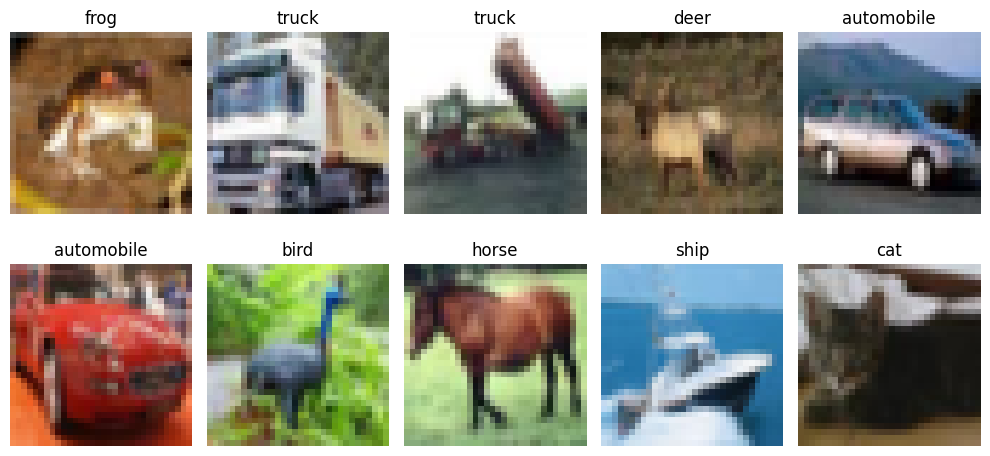

In [5]:
# Visualize Sample Images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
# Preprocessing

# Normalize pixel values (0-255 → 0-1)
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flatten images for ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized Train Shape:", x_train_norm.shape)
print("Normalized Test Shape :", x_test_norm.shape)

print("Flattened Train Shape:", x_train_flat.shape)
print("Flattened Test Shape :", x_test_flat.shape)

print("Pixel Range:",
      x_train_norm.min(), "to", x_train_norm.max())

Normalized Train Shape: (50000, 32, 32, 3)
Normalized Test Shape : (10000, 32, 32, 3)
Flattened Train Shape: (50000, 3072)
Flattened Test Shape : (10000, 3072)
Pixel Range: 0.0 to 1.0


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
# 🔹 Part 1: ANN Model
# ANN treats images as flat vectors, so it cannot preserve spatial features.
# This helps students understand why CNN is better for images.

ann_model = models.Sequential([
    tf.keras.Input(shape=(3072,)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2316 - loss: 2.1280 - val_accuracy: 0.3044 - val_loss: 1.9012
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3126 - loss: 1.8851 - val_accuracy: 0.3622 - val_loss: 1.7953
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3313 - loss: 1.8326 - val_accuracy: 0.3560 - val_loss: 1.8027
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3426 - loss: 1.7989 - val_accuracy: 0.3882 - val_loss: 1.7424
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3545 - loss: 1.7728 - val_accuracy: 0.3998 - val_loss: 1.7006
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3620 - loss: 1.7468 - val_accuracy: 0.4100 - val_loss: 1.7008
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3760 - loss: 1.7228 - val_accuracy: 0.4254 - val_loss: 1.6632
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3791 - loss: 1.7078 - val_acc

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4304 - loss: 1.6225
ANN Test Accuracy: 0.426800012588501


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
# 🔹 Part 2: CNN Model
# CNN preserves spatial relationships using convolution and pooling.

cnn_model = models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.4034 - loss: 1.8365 - val_accuracy: 0.5836 - val_loss: 1.1767
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6010 - loss: 1.1354 - val_accuracy: 0.5402 - val_loss: 1.3622
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6662 - loss: 0.9510 - val_accuracy: 0.6232 - val_loss: 1.0764
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7110 - loss: 0.8177 - val_accuracy: 0.5904 - val_loss: 1.3223
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.7474 - loss: 0.7173 - val_accuracy: 0.5414 - val_loss: 1.5876
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.7715 - loss: 0.6353 - val_accuracy: 0.6020 - val_loss: 1.2325
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.7989 - loss: 0.5620 - val_accuracy: 0.4390 - val_loss: 2.2558
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.8146 - loss: 0.5140 - 

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6820 - loss: 1.2319
CNN Test Accuracy: 0.6830999851226807


## 📈 Compare Learning Curves

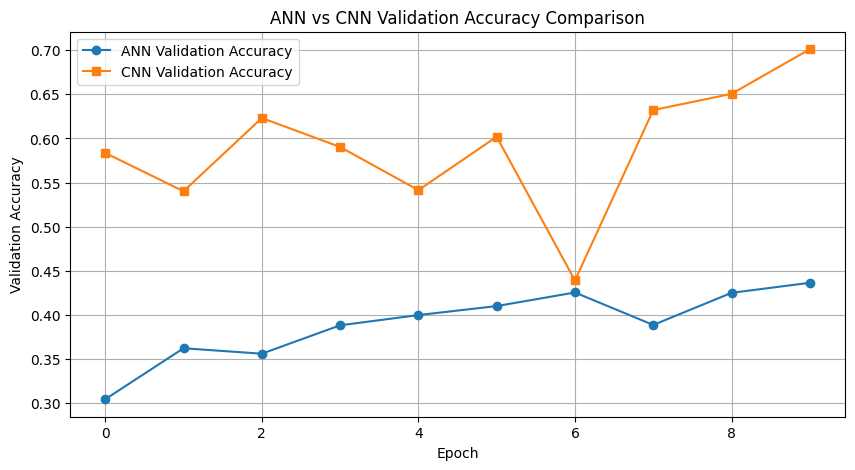

In [11]:
# 📈 Compare Learning Curves (Mentor Requirement 1)

plt.figure(figsize=(10, 5))

plt.plot(
    ann_history.history['val_accuracy'],
    marker='o',
    label='ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    marker='s',
    label='CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [12]:
# 🚀 Training Strategy Upgrade: Data Augmentation

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,                 # Beginner Task
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.2712 - loss: 2.0505 - val_accuracy: 0.4378 - val_loss: 1.5266
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.4290 - loss: 1.5842 - val_accuracy: 0.5100 - val_loss: 1.3500
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.4837 - loss: 1.4488 - val_accuracy: 0.4768 - val_loss: 1.4313
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.5200 - loss: 1.3619 - val_accuracy: 0.5634 - val_loss: 1.2223
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5520 - loss: 1.2754 - val_accuracy: 0.5840 - val_loss: 1.1424
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5750 - loss: 1.2282 - val_accuracy: 0.5850 - val_loss: 1.1733
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.5940 - loss: 1.1860 - val_accuracy: 0.6398 - val_loss: 1.0411
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6095 - loss: 1.1374 - 

In [13]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7170 - loss: 0.8212
Augmented CNN Test Accuracy: 0.7181000113487244


# 📊 Final Comparison Table

In [14]:
# Include Augmented CNN also in the comparison table

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4268
1,CNN,0.6831
2,Augmented CNN,0.7181


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

### ✅ My Completed Work

- Increased ANN depth using an enhanced model (more Dense layers)
- Used CNN with 32 → 64 → 128 filters
- Trained CNN for up to 20 epochs
- Applied EarlyStopping in augmented CNN training
- Used data augmentation (RandomFlip, RandomRotation, RandomZoom)

### 📊 Final Results
- ANN Accuracy: ~42%
- CNN Accuracy: ~68%
- Augmented CNN Accuracy: ~71%

### 🧠 Observation
CNN significantly outperforms ANN due to spatial feature extraction.
Data augmentation further improves generalization and reduces overfitting.

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**